In [1]:
## Importing Libraries

import os
import random

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from PIL import Image

plt.style.use("ggplot")

print("Libraries Imported.")

Libraries Imported.


In [ ]:
## Loading Datasets

DATASET_PATH = r"Dataset"

TRAIN_CSV = os.path.join(DATASET_PATH, "train.csv")
TEST_CSV = os.path.join(DATASET_PATH, "test.csv")

TRAIN_IMAGES = os.path.join(DATASET_PATH, "train")
TEST_IMAGES = os.path.join(DATASET_PATH, "test")

print("Datasets Loaded Successfully.")

Datasets Loaded Successfully.


In [3]:
## Converting Datasets into DataFrame

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Datasets converted to DataFrame.")

Datasets converted to DataFrame.


In [4]:
## Finding Dataset Information (Train Dataset)

print("=" * 50)
print("Training Dataset Shape")
print("=" * 50)
print(train_df.shape)
print()
print("=" * 50)
print("Training Dataset Head")
print("=" * 50)
print(train_df.head())

Training Dataset Shape
(1785, 9)

Training Dataset Head
                    sample_id              image_path Sampling_Date State  \
0  ID1011485656__Dry_Clover_g  train/ID1011485656.jpg      2015/9/4   Tas   
1    ID1011485656__Dry_Dead_g  train/ID1011485656.jpg      2015/9/4   Tas   
2   ID1011485656__Dry_Green_g  train/ID1011485656.jpg      2015/9/4   Tas   
3   ID1011485656__Dry_Total_g  train/ID1011485656.jpg      2015/9/4   Tas   
4         ID1011485656__GDM_g  train/ID1011485656.jpg      2015/9/4   Tas   

           Species  Pre_GSHH_NDVI  Height_Ave_cm   target_name   target  
0  Ryegrass_Clover           0.62         4.6667  Dry_Clover_g   0.0000  
1  Ryegrass_Clover           0.62         4.6667    Dry_Dead_g  31.9984  
2  Ryegrass_Clover           0.62         4.6667   Dry_Green_g  16.2751  
3  Ryegrass_Clover           0.62         4.6667   Dry_Total_g  48.2735  
4  Ryegrass_Clover           0.62         4.6667         GDM_g  16.2750  


In [5]:
## Finding Dataset Information (Test Dataset)

print("=" * 50)
print("Test Dataset Shape")
print("=" * 50)
print(test_df.shape)
print("=" * 50)
print("Test Dataset Head")
print("=" * 50)
print(test_df.head())

Test Dataset Shape
(5, 3)
Test Dataset Head
                    sample_id             image_path   target_name
0  ID1001187975__Dry_Clover_g  test/ID1001187975.jpg  Dry_Clover_g
1    ID1001187975__Dry_Dead_g  test/ID1001187975.jpg    Dry_Dead_g
2   ID1001187975__Dry_Green_g  test/ID1001187975.jpg   Dry_Green_g
3   ID1001187975__Dry_Total_g  test/ID1001187975.jpg   Dry_Total_g
4         ID1001187975__GDM_g  test/ID1001187975.jpg         GDM_g


In [6]:
## Training DataFrame Information

print("=" * 50)
print(train_df.info())
print("=" * 50)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1785 entries, 0 to 1784
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sample_id      1785 non-null   object 
 1   image_path     1785 non-null   object 
 2   Sampling_Date  1785 non-null   object 
 3   State          1785 non-null   object 
 4   Species        1785 non-null   object 
 5   Pre_GSHH_NDVI  1785 non-null   float64
 6   Height_Ave_cm  1785 non-null   float64
 7   target_name    1785 non-null   object 
 8   target         1785 non-null   float64
dtypes: float64(3), object(6)
memory usage: 125.6+ KB
None


In [7]:
## Checking Missing Values

missing = train_df.isnull().sum()
display(missing)

sample_id        0
image_path       0
Sampling_Date    0
State            0
Species          0
Pre_GSHH_NDVI    0
Height_Ave_cm    0
target_name      0
target           0
dtype: int64

In [8]:
## Checking Duplicate Rows

duplicates = train_df.duplicated().sum()
print("Duplicate Rows: ", duplicates)

Duplicate Rows:  0


In [9]:
## Datasets Statistics

train_df.describe(include = "all")

,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target
count,1785,1785,1785,1785,1785,1785.000000,1785.000000,1785,1785.000000
unique,1785,357,28,4,15,NaN,NaN,5,NaN
top,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/6/26,Tas,Ryegrass_Clover,NaN,NaN,Dry_Clover_g,NaN
freq,1,5,185,690,490,NaN,NaN,357,NaN
mean,NaN,NaN,NaN,NaN,NaN,0.657423,7.595985,NaN,24.782295
std,NaN,NaN,NaN,NaN,NaN,0.151972,10.273725,NaN,25.823738
min,NaN,NaN,NaN,NaN,NaN,0.160000,1.000000,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,0.560000,3.000000,NaN,4.818200
50%,NaN,NaN,NaN,NaN,NaN,0.690000,4.000000,NaN,18.200000
75%,NaN,NaN,NaN,NaN,NaN,0.770000,7.000000,NaN,35.940600


In [10]:
## Finding Column Names

print("Columns Present: ")
print()
for column in train_df.columns:
    print(column)

Columns Present: 

sample_id
image_path
Sampling_Date
State
Species
Pre_GSHH_NDVI
Height_Ave_cm
target_name
target


In [11]:
## Checking Number of Unique Images in the Dataset

print("Unique Images: ", train_df["image_path"].nunique())

Unique Images:  357


In [12]:
## Checking Number of Targets

print(train_df["target_name"].value_counts())

target_name
Dry_Clover_g    357
Dry_Dead_g      357
Dry_Green_g     357
Dry_Total_g     357
GDM_g           357
Name: count, dtype: int64


In [13]:
## Pivoting Dataset

pivot_df = train_df.pivot(index = "image_path", columns = "target_name", values = "target").reset_index()
display(pivot_df.head())

target_name,image_path,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
0,train/ID1011485656.jpg,0.0000,31.9984,16.2751,48.2735,16.2750
1,train/ID1012260530.jpg,0.0000,0.0000,7.6000,7.6000,7.6000
2,train/ID1025234388.jpg,6.0500,0.0000,0.0000,6.0500,6.0500
3,train/ID1028611175.jpg,0.0000,30.9703,24.2376,55.2079,24.2376
4,train/ID1035947949.jpg,0.4343,23.2239,10.5261,34.1844,10.9605


In [14]:
## Verifying Shape

print("Pivot Dataset Shape: ", pivot_df.shape)

Pivot Dataset Shape:  (357, 6)


In [15]:
## Checking Missing Values After Pivot

pivot_df.isnull().sum()

target_name
image_path      0
Dry_Clover_g    0
Dry_Dead_g      0
Dry_Green_g     0
Dry_Total_g     0
GDM_g           0
dtype: int64

In [16]:
## Creating Correlation Matrix

correlation = pivot_df.drop(columns = ["image_path"]).corr()
display(correlation)

target_name,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
target_name,,,,,
Dry_Clover_g,1.000000,-0.175548,-0.276582,0.104185,0.204213
Dry_Dead_g,-0.175548,1.000000,0.095554,0.453912,0.012028
Dry_Green_g,-0.276582,0.095554,1.000000,0.830315,0.884257
Dry_Total_g,0.104185,0.453912,0.830315,1.000000,0.896441
GDM_g,0.204213,0.012028,0.884257,0.896441,1.000000


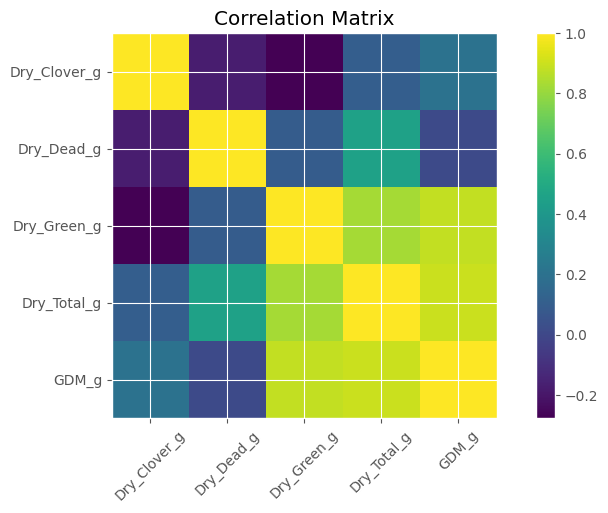

In [17]:
## Creating Correlation HeatMap

plt.figure(figsize = (10, 5))
plt.imshow(correlation, cmap = "viridis")
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation = 45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

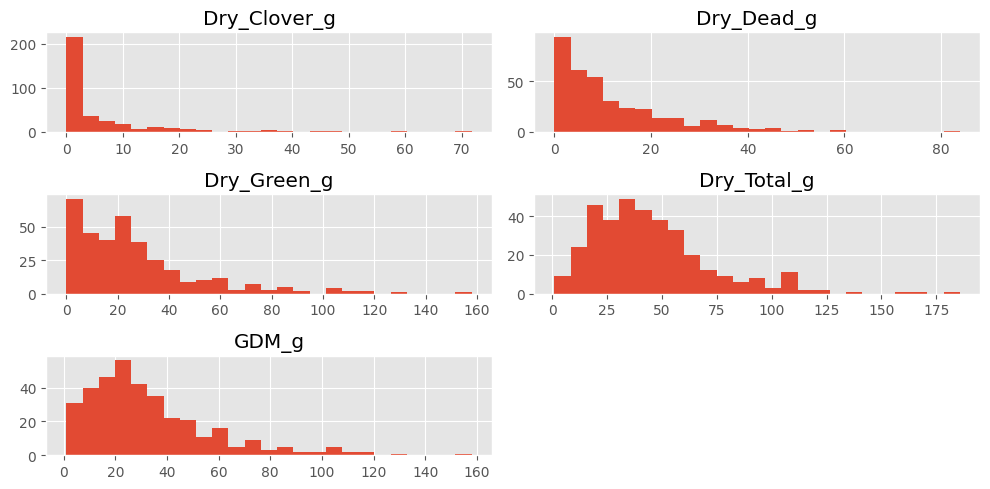

In [18]:
## Creating Distribution of Biomass Targets

pivot_df.hist(figsize = (10, 5), bins = 25)
plt.tight_layout()
plt.show()

In [19]:
print("=" * 50)
print("Biomass Target Statistics")
print("=" * 50)

display(pivot_df.drop(columns="image_path").describe().T)

Biomass Target Statistics


,count,mean,std,min,25%,50%,75%,max
target_name,,,,,,,,
Dry_Clover_g,357.0,6.649692,12.117761,0.00,0.0000,1.4235,7.2429,71.7865
Dry_Dead_g,357.0,12.044548,12.402007,0.00,3.2000,7.9809,17.6378,83.8407
Dry_Green_g,357.0,26.624722,25.401232,0.00,8.8000,20.8000,35.0834,157.9836
Dry_Total_g,357.0,45.318097,27.984015,1.04,25.2715,40.3000,57.8800,185.7000
GDM_g,357.0,33.274414,24.935822,1.04,16.0261,27.1082,43.6757,157.9836


In [20]:
## Doing Resolution Check

widths = []
heights = []

for image in pivot_df["image_path"]:
    path = os.path.join(DATASET_PATH, image)
    img = Image.open(path)
    widths.append(img.width)
    heights.append(img.height)

print("=" * 50)
print("Image Resolution Analysis")
print("=" * 50)

print("Total Images: ", len(widths))
print("Unique Widths:", sorted(set(widths)))
print("Unique Heights: ", sorted(set(heights)))
print()
print("Minimum Width: ", min(widths))
print("Maximum Width: ", max(widths))
print()
print("Minimum Height: ", min(heights))
print("Maximum Height: ", max(heights))

Image Resolution Analysis
Total Images:  357
Unique Widths: [2000]
Unique Heights:  [1000]

Minimum Width:  2000
Maximum Width:  2000

Minimum Height:  1000
Maximum Height:  1000


In [21]:
## Verifying RGB Channels

sample = Image.open(os.path.join(DATASET_PATH, pivot_df.iloc[0]["image_path"]))
print(sample.mode)

RGB


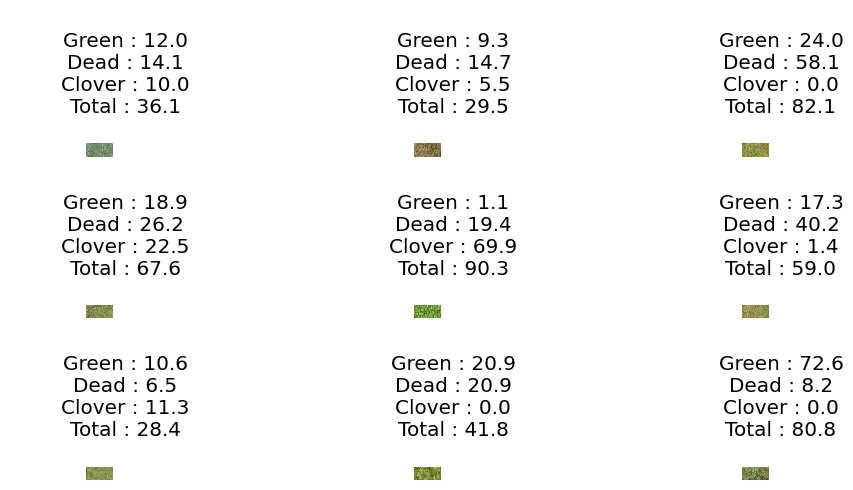

In [22]:
## Checking Random Images

fig, axes = plt.subplots(3,3, figsize=(10, 5))
indices = random.sample(range(len(pivot_df)), 9)

for ax, idx in zip(axes.flatten(), indices):
    row = pivot_df.iloc[idx]
    img = mpimg.imread(os.path.join(DATASET_PATH, row["image_path"]))
    ax.imshow(img)

    ax.set_title(
        f"""
        Green : {row['Dry_Green_g']:.1f}
        Dead : {row['Dry_Dead_g']:.1f}
        Clover : {row['Dry_Clover_g']:.1f}
        Total : {row['Dry_Total_g']:.1f}
        """
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

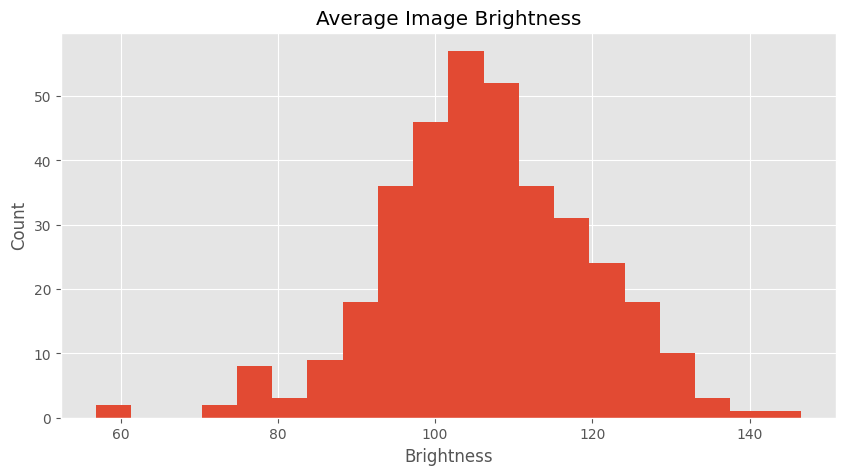

In [23]:
## Analysing Image Brightness

brightness = []

for image in pivot_df["image_path"]:
    img = Image.open(os.path.join(DATASET_PATH, image))

    img = np.array(img)
    brightness.append(img.mean())

plt.figure(figsize=(10, 5))
plt.hist(brightness, bins=20)

plt.title("Average Image Brightness")
plt.xlabel("Brightness")
plt.ylabel("Count")
plt.show()

In [24]:
## Creating Dataset Summary

print("=" * 50)
print("Dataset Summary")
print("=" * 50)

print(f"Training Images : {len(pivot_df)}")
print(f"Targets         : {pivot_df.shape[1]-1}")
print(f"Missing Values  : {pivot_df.isnull().sum().sum()}")

print(f"Duplicate Rows  : {duplicates}")
print(f"Image Width     : {widths[0]}")
print(f"Image Height    : {heights[0]}")


Dataset Summary
Training Images : 357
Targets         : 5
Missing Values  : 0
Duplicate Rows  : 0
Image Width     : 2000
Image Height    : 1000
